# Low-level single-point 2D functions

**Author:** Hannu Parviainen </br>
**Edited:** 12 June 2026

This notebook tours the low-level single-point 2D API in `meepmeep.numba2d`. The idea: solve a 5th-order Taylor expansion of the planet's sky-plane position around a single expansion point near the transit, and evaluate everything a transit model needs from that one coefficient matrix. A single expansion is accurate within a window around the expansion point, so this is the cheapest path when only the times near the transit matter.

The functions are plain Numba-jitted functions and overload dispatchers: they can be called from Python or from inside your own `@njit` kernels with no wrapper overhead. The method is described in Parviainen & Korth (2020), MNRAS 499, 3356.

If you want the same functionality behind a friendlier interface, use `meepmeep.knot2d.Knot2D`. For full-orbit quantities (phase curves, radial velocities, the line-of-sight coordinate), use `meepmeep.Orbit` or the 3D API in `meepmeep.numba3d`.

In [1]:
from numpy import *
from matplotlib.pyplot import *

In [2]:
import sys
sys.path.append('..')

In [3]:
from matplotlib.pyplot import rc, subplots, setp
rc('figure', figsize=(13,4))

from meepmeep.numba2d import (solve2d, solve2d_d, pos, pos_d, sep, sep_c, sep_d,
                              find_contact_point, bounding_box,
                              t12, t14, t23, t34, find_z_min)

## Setup

MeepMeep works in days, radians, and stellar radii everywhere. We use a slightly eccentric test orbit and sample a narrow window around the transit centre, which is the regime the single-point approach is meant for.

The knot offset `tk` places the expansion point at `tc + tk` on the observation time axis. `tk = 0` expands at the transit centre, which is what you want for transit modelling; a nonzero `tk` is useful when you need several expansion points along the orbit (that is what `Orbit` automates).

In [4]:
pars = ['t_0', 'p', 'a', 'i', 'e', '\\omega', '\\Omega']

In [5]:
t0, p, a, i, e, w, l = 0.20, 2.2, 8.0, 0.49*pi, 0.15, 0.25*pi, 0.0*pi
times = linspace(t0-0.1, t0+0.1, 1000)
tk = 0.0

## Solve the Taylor series

First we solve the Taylor series at the expansion point. `solve2d(tk, p, a, i, e, w, lan)` returns a `(2, 5)` coefficient matrix `c`: the rows are the sky-plane dimensions (x, y) and the columns the Taylor orders from position to snap, pre-scaled by the factorials. `solve2d_d` returns the same matrix together with a `(7, 2, 5)` tensor `dc` holding the partial derivatives of the coefficients with respect to the orbital parameters in the order $(t_0, p, a, i, e, \omega, \Omega)$.

Solving the series is the expensive step (one Newton-Raphson solve plus finite rotations); everything after it is polynomial evaluation. Let's check that the value-only and derivative-returning solvers agree.

In [6]:
c, dc = solve2d_d(tk, p, a, i, e, w, l)

round(c-solve2d(tk, p, a, i, e, w, l), 10)

array([[ 0., -0., -0.,  0., -0.],
       [ 0.,  0., -0., -0.,  0.]])

In [7]:
c.shape, dc.shape

((2, 5), (7, 2, 5))

## Evaluating the series

Each quantity comes in two variants. The *centered* variant (`pos_c`, `sep_c`) takes a time relative to the expansion point and is the fastest. The *direct* variant (`pos`, `sep`) takes absolute times together with `tc`, `p`, and the knot offset `tk`, and folds each time to the epoch nearest to the knot internally, so a single coefficient matrix evaluates any transit of the orbit. The derivative-returning versions add a `_d` (direct) or `_cd` (centered) suffix.

Both variants give the same answer when the bookkeeping is done by hand, and epoch folding means a time shifted by a hundred periods lands on the same curve:

In [8]:
print(abs(sep_c(times - (t0 + tk), c) - sep(times, t0, p, c, tk)).max())
print(abs(sep(times + 100*p, t0, p, c, tk) - sep(times, t0, p, c, tk)).max())

0.0
6.266098750984384e-13


### Sky-projected separation

`sep` returns the sky-projected separation between the centers of the star and planet, in units of the stellar radius - the $b(t)$ quantity transit light curve models consume. It is always non-negative, so it does not separate transits from secondary eclipses; that needs the line-of-sight coordinate from the 3D API.

`sep_d` returns the separation together with its partial derivatives with respect to the seven orbital parameters: for `n` input times, `d` has shape `(n,)` and `dd` shape `(n, 7)`. First, check that the two evaluators agree on the values.

In [9]:
d, dd = sep_d(times, t0, p, c, dc, tk)

max(abs(d - sep(times, t0, p, c, tk)))

np.float64(0.0)

[Text(0.5, 0, 'Time [d]'),
 Text(0.5, 0, 'Time [d]'),
 Text(0.5, 0, 'Time [d]'),
 Text(0.5, 0, 'Time [d]')]

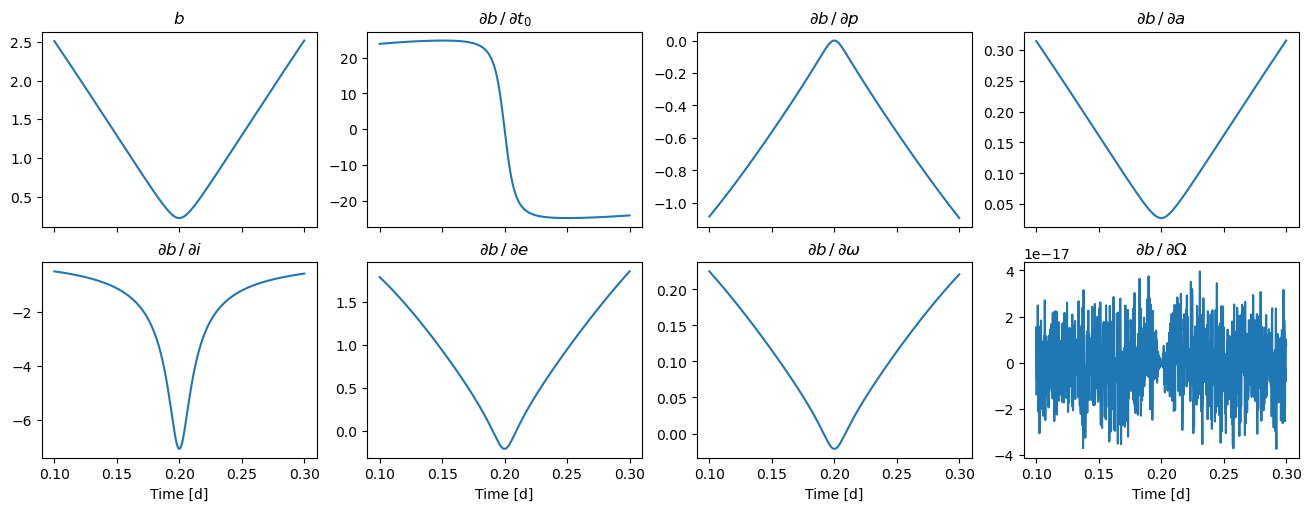

In [10]:
fig, axs = subplots(2, 4, figsize=(13, 5), constrained_layout=True, sharex='all')
axs.flat[0].plot(times, d)
axs.flat[0].set_title('$b$')

for j, dp in enumerate(dd.T):
    axs.flat[j+1].plot(times, dp)
    axs.flat[j+1].set_title(fr"$\partial b\,/\,\partial {pars[j]}$")
setp(axs[-1, :], xlabel='Time [d]')

### Sky-plane position

`pos` returns the x and y coordinates separately, and `pos_d` adds the `(n, 7)` derivative arrays for both.

In [11]:
x, y, dx, dy = pos_d(times, t0, p, c, dc, tk)

[max(abs(a1 - a2)) for a1, a2 in zip((x, y), pos(times, t0, p, c, tk))]

[np.float64(0.0), np.float64(0.0)]

[Text(0.5, 0, 'Time [d]'),
 Text(0.5, 0, 'Time [d]'),
 Text(0.5, 0, 'Time [d]'),
 Text(0.5, 0, 'Time [d]')]

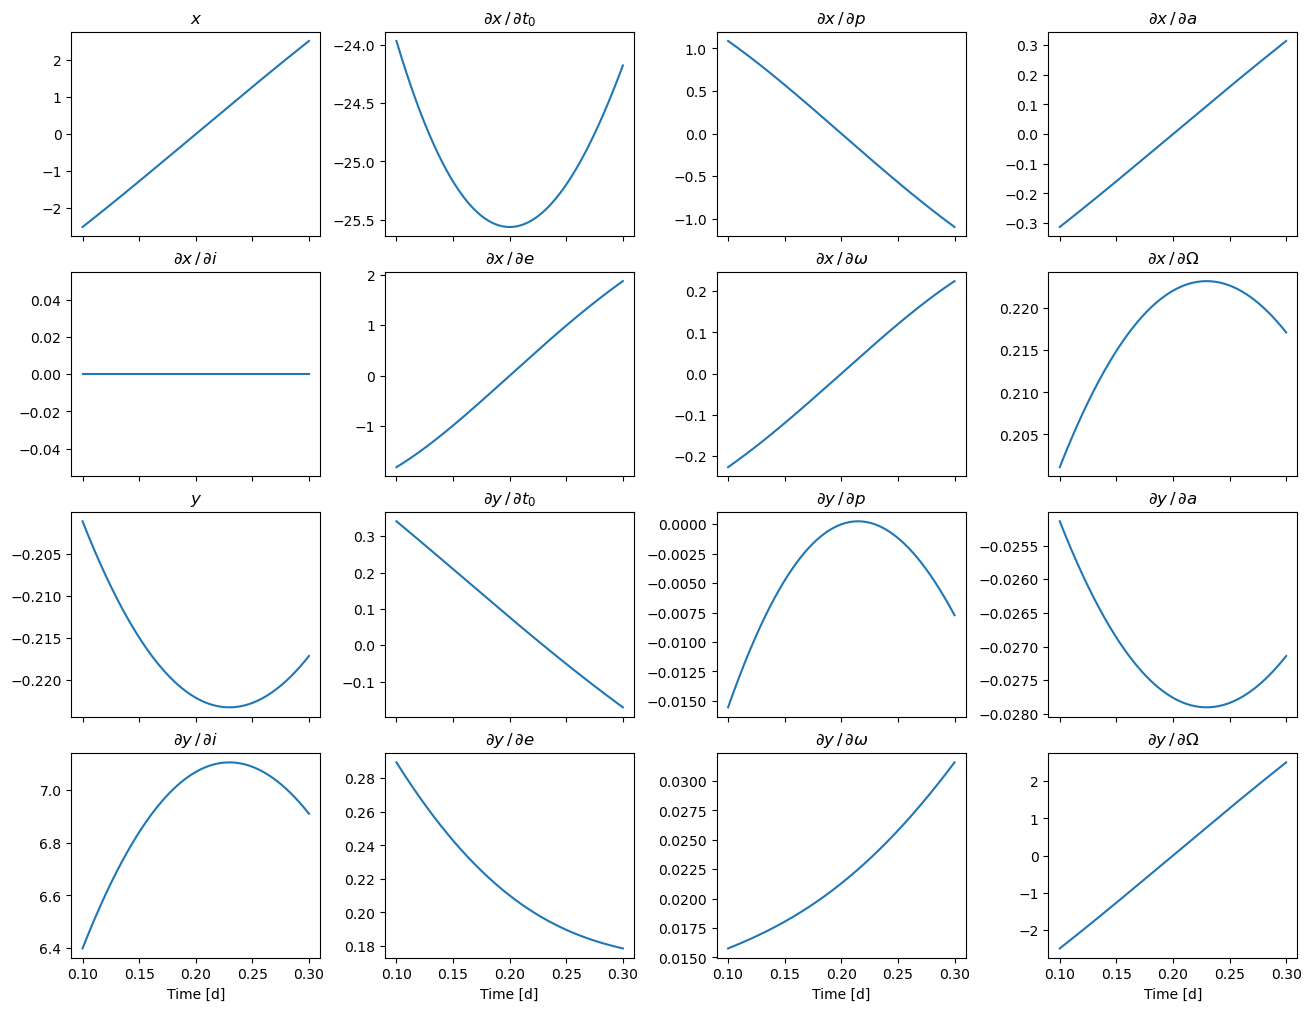

In [12]:
fig, axs = subplots(4, 4, figsize=(13, 10), constrained_layout=True, sharex='all')
axs.flat[0].plot(times, x)
axs.flat[0].set_title('$x$')
for j, dp in enumerate(dx.T):
    axs.flat[j+1].plot(times, dp)
    axs.flat[j+1].set_title(fr"$\partial x\,/\,\partial {pars[j]}$")

axs.flat[8].plot(times, y)
axs.flat[8].set_title('$y$')
for j, dp in enumerate(dy.T):
    axs.flat[j+9].plot(times, dp)
    axs.flat[j+9].set_title(fr"$\partial y\,/\,\partial {pars[j]}$")
setp(axs[-1, :], xlabel='Time [d]')

## Transit geometry

The geometry helpers derive the transit shape directly from the coefficient matrix: contact point times (`find_contact_point`, or the `t1` and `t4` shorthands), durations (`t14`, `t23`, `t12`, `t34`), the transit bounding box, and the time and value of the minimum separation (`find_z_min` - the minimum is the impact parameter). They take the planet-star radius ratio `k` where relevant.

One thing to keep in mind: these work in *knot-centred* time. They return offsets from the expansion point, not absolute times; add `tc + tk` to place them on the observation time axis (the high-level `Knot2D` methods do this conversion for you).

In [13]:
k = 0.1

tt1, tt4 = bounding_box(k, c)
print(f"Transit window: {t0 + tk + tt1:.4f} .. {t0 + tk + tt4:.4f} [d]")
print(f"T14 (total):   {24 * t14(k, c):5.3f} h")
print(f"T23 (full):    {24 * t23(k, c):5.3f} h")
print(f"T12 (ingress): {24 * t12(k, c):5.3f} h")
print(f"T34 (egress):  {24 * t34(k, c):5.3f} h")

tmin, b_impact = find_z_min(0.0, c)
print(f"Impact parameter: {b_impact:.3f} at t = {t0 + tk + tmin:.4f}")

Transit window: 0.1577 .. 0.2423 [d]
T14 (total):   2.031 h


T23 (full):    1.642 h
T12 (ingress): 0.194 h
T34 (egress):  0.194 h


Impact parameter: 0.222 at t = 0.2000


[Text(0.5, 0, 'Time [d]'),
 Text(0, 0.5, 'Projected separation [R$_\\star$]'),
 0.1,
 0.30000000000000004]

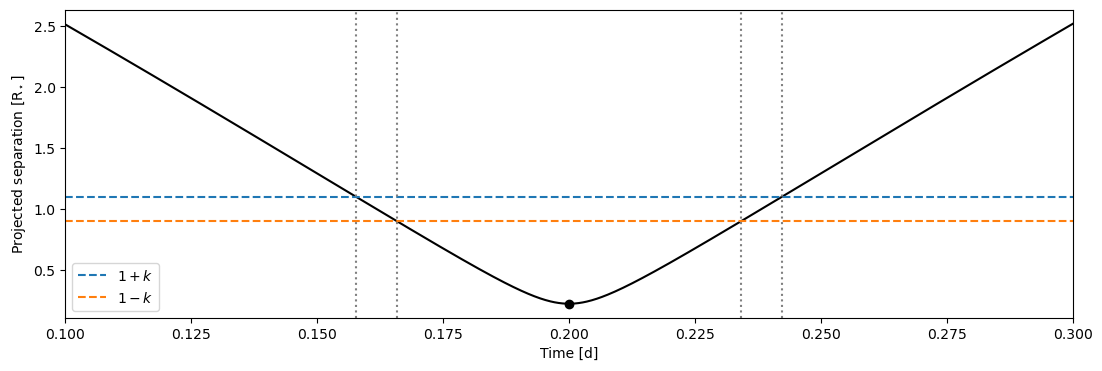

In [14]:
cps = [t0 + tk + find_contact_point(k, pt, c) for pt in (1, 2, 3, 4)]

fig, ax = subplots()
ax.plot(times, d, 'k')
ax.axhline(1 + k, ls='--', c='C0', label='$1+k$')
ax.axhline(1 - k, ls='--', c='C1', label='$1-k$')
for cp in cps:
    ax.axvline(cp, ls=':', c='0.5')
ax.plot(t0 + tk + tmin, b_impact, 'ok')
ax.legend()
setp(ax, xlabel='Time [d]', ylabel=r'Projected separation [R$_\star$]',
     xlim=times[[0, -1]])

## Accuracy

How far from the expansion point can a single 5th-order expansion be trusted? Compare against the exact Newton-Raphson solver the package itself is tested against. The error is tiny near the knot and grows steeply away from it. If you need a wider window, add expansion points - that is what `Orbit` does - rather than stretching a single one.

[Text(0.5, 0, 'Time - t$_0$ [d]'),
 Text(0, 0.5, '$|b_\\mathrm{taylor} - b_\\mathrm{newton}|$ [R$_\\star$]')]

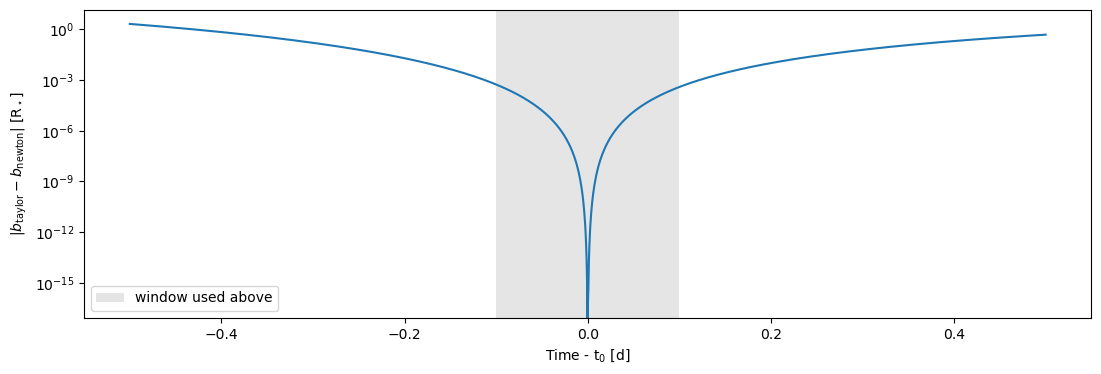

In [15]:
from meepmeep.backends.numba.newton import xyz_newton_v

times_w = linspace(t0 - 0.5, t0 + 0.5, 2000)
b_taylor = sep(times_w, t0, p, c, tk)
xn, yn, zn = xyz_newton_v(times_w, t0, p, a, i, e, w)
b_newton = sqrt(xn**2 + yn**2)

fig, ax = subplots()
ax.semilogy(times_w - t0, abs(b_taylor - b_newton))
ax.axvspan(-0.1, 0.1, fc='k', alpha=0.1, label='window used above')
ax.legend()
setp(ax, xlabel='Time - t$_0$ [d]', ylabel=r'$|b_\mathrm{taylor} - b_\mathrm{newton}|$ [R$_\star$]')

## Calling from your own numba code

The main reason to use the low-level API directly: every function here can be called from inside user `@njit` kernels with no wrapper overhead. The scalar-or-array dispatch happens at compile time.

In [16]:
from numba import njit

@njit(fastmath=True)
def in_transit_fraction(times, t0, p, k, c, tk):
    b = sep(times, t0, p, c, tk)
    n = 0
    for j in range(b.size):
        if b[j] < 1.0 + k:
            n += 1
    return n / b.size

in_transit_fraction(times, t0, p, k, c, tk)

0.423

## Parallelisation

Every vector kernel has a parallel twin: `_sep_v` (serial loop) and `_sep_vp` (`numba.prange` over threads), and the same for the gradient kernels. The public dispatchers (`sep`, `sep_d`, ...) always route to the serial kernels; the parallel twins are opt-in through `Knot2D(parallel=True)`, which switches over only above ~1e5 points in value mode and ~1e4 points in derivative mode. The benchmark below shows why: below those sizes the parallel-region launch overhead eats the gains, and the gradient kernels (7x more work per sample) start profiting earlier than the value kernels.

The kernels are private (leading underscore) and imported here only to demonstrate the scaling - don't build against them.

In [17]:
from meepmeep.backends.numba.point2d import _sep_v, _sep_vp
from meepmeep.backends.numba.point2dd import _sep_d_v, _sep_d_vp

In [18]:
times_a = linspace(t0-0.1, t0+0.1, 1000)
times_b = linspace(t0-0.1, t0+0.1, 10000)
times_c = linspace(t0-0.1, t0+0.1, 50000)
times_d = linspace(t0-0.1, t0+0.1, 100000)
ns = [t.size for t in (times_a, times_b, times_c, times_d)]

In [19]:
from timeit import repeat

In [20]:
_sep_v(times_a, t0, p, c, tk), _sep_vp(times_a, t0, p, c, tk)
_sep_d_v(times_a, t0, p, c, dc, tk), _sep_d_vp(times_a, t0, p, c, dc, tk)

def bench(call):
    return [1e3 * min(repeat(call.format(case=case), repeat=6, number=100, globals=globals())) / 100
            for case in 'abcd']

tv   = bench('_sep_v(times_{case}, t0, p, c, tk)')
tvp  = bench('_sep_vp(times_{case}, t0, p, c, tk)')
tdv  = bench('_sep_d_v(times_{case}, t0, p, c, dc, tk)')
tdvp = bench('_sep_d_vp(times_{case}, t0, p, c, dc, tk)')

print(f"{'n':>7}  {'sep':>9} {'sep par':>9} {'speedup':>8}  {'sep_d':>9} {'sep_d par':>9} {'speedup':>8}")
for j, n in enumerate(ns):
    print(f"{n:7d}  {tv[j]:6.3f} ms {tvp[j]:6.3f} ms {tv[j]/tvp[j]:7.1f}x  "
          f"{tdv[j]:6.3f} ms {tdvp[j]:6.3f} ms {tdv[j]/tdvp[j]:7.1f}x")

      n        sep   sep par  speedup      sep_d sep_d par  speedup
   1000   0.002 ms  0.017 ms     0.1x   0.017 ms  0.053 ms     0.3x
  10000   0.007 ms  0.031 ms     0.2x   0.171 ms  0.081 ms     2.1x
  50000   0.035 ms  0.037 ms     0.9x   0.981 ms  0.221 ms     4.4x
 100000   0.069 ms  0.051 ms     1.4x   1.665 ms  0.344 ms     4.8x


[Text(0, 0.5, 'Time per call [ms]')]

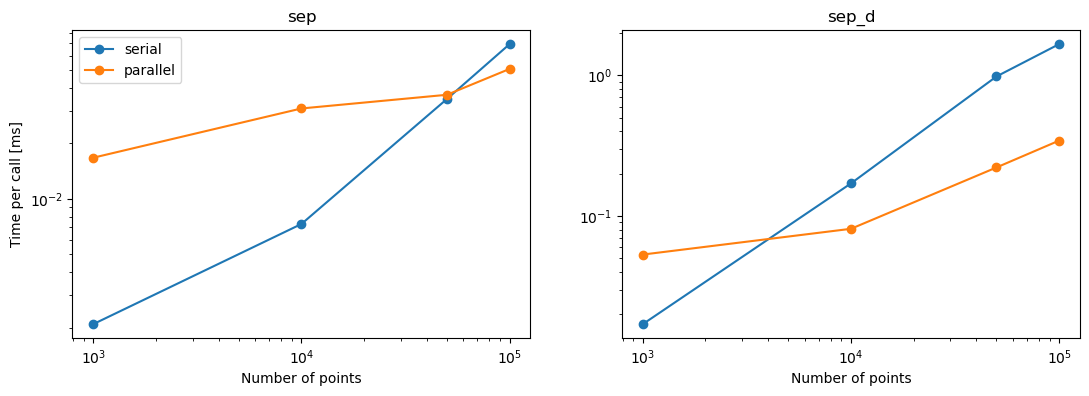

In [21]:
fig, axs = subplots(1, 2, figsize=(13, 4), sharex='all')
axs[0].loglog(ns, tv, 'o-', label='serial')
axs[0].loglog(ns, tvp, 'o-', label='parallel')
axs[1].loglog(ns, tdv, 'o-', label='serial')
axs[1].loglog(ns, tdvp, 'o-', label='parallel')
axs[0].set_title('sep')
axs[1].set_title('sep_d')
axs[0].legend()
setp(axs, xlabel='Number of points')
setp(axs[0], ylabel='Time per call [ms]')

---

<center> &copy;2026 Hannu Parviainen </center>